# 第53篇 | 模型评估：准确率、召回率、F1、ROC-AUC

> 这是「数据分析从入门到精通」系列的第 53 篇。学了好几个分类算法，这篇来解决一个核心问题——模型到底好不好，该怎么评估？只看准确率会踩大坑，这篇带你搞懂准确率、召回率、F1、ROC-AUC 各自的意义和使用场景。

嗨，我是小荷～ 今天学一个超级重要的话题：**如何正确评估一个分类模型**。

---

## 一、为什么准确率会骗人？

**场景假设**：
- 某疾病发病率1%，你建了个模型，预测所有人都是"健康"
- 准确率 = 99%！但模型一点用都没有

**问题所在**：类别不平衡时，准确率毫无意义。


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, confusion_matrix, classification_report,
                            roc_curve, auc, precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("分类模型评估指标全解析")

# 生成不平衡数据（模拟疾病检测）
np.random.seed(42)
X, y = make_classification(n_samples=1000, # 总样本数：1000 个
                           n_features=20,  # 总特征数：20 个
                           n_informative=10, # 有用特征：10 个（真正影响分类的）
                           n_redundant=5,   # 冗余特征：5 个（没用、重复的）
                           weights=[0.95, 0.05],  # 类别比例：95% 一类，5% 一类（极度不平衡！）
                           flip_y=0.1,  # 10% 标签噪声（故意标错，模拟真实数据）
                           random_state=42)  # 固定随机种子，结果可复现

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=42, stratify=y)

print(f"数据分布: {np.bincount(y)}")  # 因为有噪声 flip_y，所以不是严格 950 & 50
print(f"正例比例: {y.mean():.1%}")

# 训练模型
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 计算准确率
acc = accuracy_score(y_test, y_pred)
print(f"\n模型准确率: {acc:.2%}")

# 对比"全预测为负例"的准确率
dummy_acc = (y_test == 0).mean()
print(f"全预测为负例的准确率: {dummy_acc:.2%}")

# 对比"全预测为负例"的准确率
dummy_acc = (y_test == 1).mean()
print(f"全预测为正例的准确率: {dummy_acc:.2%}")

分类模型评估指标全解析
数据分布: [897 103]
正例比例: 10.3%

模型准确率: 89.67%
全预测为负例的准确率: 89.67%
全预测为正例的准确率: 10.33%


这里可以看到，全预测为正例的准确率只有 10.33%， 非常低，跟它的比例差不多了。这是因为准确率（Accuracy）在样本不均衡时（如99%健康人，1%病人）会失效。

因此，我们可以利用混淆矩阵衍生出更精准的评估维度，如精确率 (Precision)、召回率 (Recall)、F1 分数 (F1-Score)作为核心评估指标，重点关注少数类（异常样本）的识别效果。

---

## 二、混淆矩阵：评估的基础

混淆矩阵（Confusion Matrix）是机器学习中用于评估分类模型性能的核心工具。它通过矩阵形式，将模型的预测结果与真实标签进行交叉对比，从而直观地展示模型在哪些类别上“混淆”了。以最基础的二分类（Binary Classification）为例，混淆矩阵是一个 2*2  的表格，包含 4 个核心象限：

真实 \ 预测|预测为正例 (Positive)|预测为反例 (Negative)|
|--|--|--|
真实为正例 (Positive)|TP (True Positive)真正例：预测正确，本来就是阳性|FN (False Negative)假反例：预测错误，漏报了|
真实为反例 (Negative)|FP (False Positive)假正例：预测错误，误报了|TN (True Negative)真反例：预测正确，本来就是阴性|

记忆捷径：

- 第一个字母（T/F）代表预测得对不对（True=对，False=错）。
- 第二个字母（P/N）代表模型的实际结果（Positive=正，Negative=反）。
例如：FP = 模型实际结果是正例（P），但预测是假（F），所以实际上是假正例，反例（误报）。

总结：混淆矩阵四要素:
TN (True Negative):  实际负例，预测对了 ✓
FP (False Positive): 实际正例，预测错了 ✗ (误报)
FN (False Negative): 实际负例，预测错了 ✗ (漏报)
TP (True Positive):  实际正例，预测对了 ✓


混淆矩阵:
                 预测
              负(0)  正(1)
实际  负(0)    269      0   (TN=269, FP=0)
      正(1)     31      0   (FN=31, TP=0)


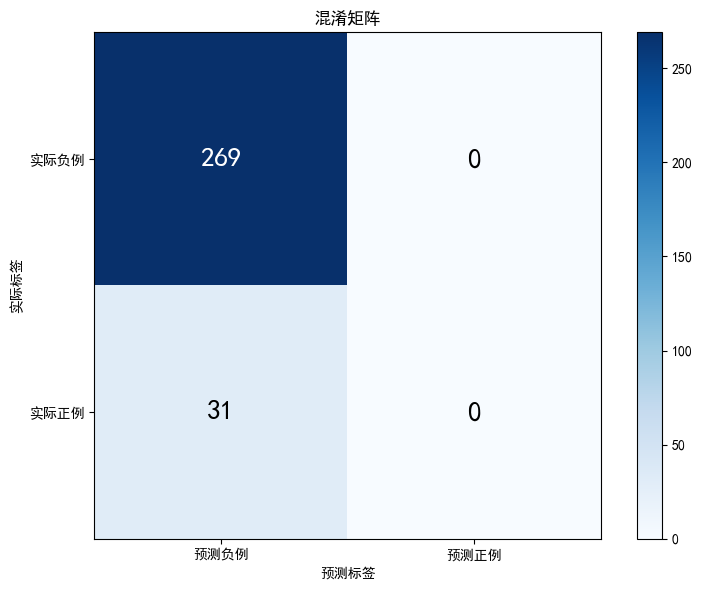

In [24]:
# 计算混淆矩阵
cm = confusion_matrix(y_test, y_pred)
print("\n混淆矩阵:")
print(f"                 预测")
print(f"              负(0)  正(1)")
print(f"实际  负(0)   {cm[0,0]:4d}   {cm[0,1]:4d}   (TN={cm[0,0]}, FP={cm[0,1]})")
print(f"      正(1)   {cm[1,0]:4d}   {cm[1,1]:4d}   (FN={cm[1,0]}, TP={cm[1,1]})")

# 可视化混淆矩阵
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=[0, 1], yticks=[0, 1],
       xticklabels=['预测负例', '预测正例'],
       yticklabels=['实际负例', '实际正例'],
       title='混淆矩阵',
       ylabel='实际标签',
       xlabel='预测标签')

# 添加数值标注
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=20, fontweight='bold')

plt.tight_layout()
plt.show()


---

## 三、核心评估指标

分类模型好不好，看这几个指标：


In [4]:
# 计算各项指标
# .ravel() 是 NumPy 的内置方法，作用是将任意多维数组展平（Flatten）为一维数组
# 解包序列：tn, fp, fn, tp，谐音“特（T）牛（N），发（F）飘（P），犯（F）难（N），特（T）拼（P）”
tn, fp, fn, tp = cm.ravel() 

print("\n核心评估指标:")
print("=" * 60)

# 准确率
accuracy = (tp + tn) / (tp + tn + fp + fn)
print(f"\n1. 准确率 (Accuracy)")
print(f"   公式: (TP+TN) / 总数")
print(f"   计算: ({tp}+{tn}) / {tp+tn+fp+fn} = {accuracy:.4f}")
print(f"   sklearn: {accuracy_score(y_test, y_pred):.4f}")
print(f"   含义: 预测正确的比例")

# 精确率
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
print(f"\n2. 精确率 (Precision)")
print(f"   公式: TP / (TP+FP)")
print(f"   计算: {tp} / ({tp}+{fp}) = {precision:.4f}")
print(f"   sklearn: {precision_score(y_test, y_pred):.4f}")
print(f"   含义: 预测为正例中，实际为正例的比例")
print(f"   关注: 误报率 (FP)")

# 召回率
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"\n3. 召回率 (Recall / Sensitivity)")
print(f"   公式: TP / (TP+FN)")
print(f"   计算: {tp} / ({tp}+{fn}) = {recall:.4f}")
print(f"   sklearn: {recall_score(y_test, y_pred):.4f}")
print(f"   含义: 实际为正例中，被正确找出的比例")
print(f"   关注: 漏报率 (FN)")

# F1分数
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"\n4. F1分数 (F1-Score)")
print(f"   公式: 2 * (Precision * Recall) / (Precision + Recall)")
print(f"   计算: 2 * ({precision:.4f} * {recall:.4f}) / ({precision:.4f} + {recall:.4f}) = {f1:.4f}")
print(f"   sklearn: {f1_score(y_test, y_pred):.4f}")
print(f"   含义: 精确率和召回率的调和平均")
print(f"   特点: 同时考虑两者，不平衡时比准确率更可靠")

# 特异度
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
print(f"\n5. 特异度 (Specificity)")
print(f"   公式: TN / (TN+FP)")
print(f"   计算: {tn} / ({tn}+{fp}) = {specificity:.4f}")
print(f"   含义: 实际为负例中，被正确识别的比例")



核心评估指标:

1. 准确率 (Accuracy)
   公式: (TP+TN) / 总数
   计算: (0+269) / 300 = 0.8967
   sklearn: 0.8967
   含义: 预测正确的比例

2. 精确率 (Precision)
   公式: TP / (TP+FP)
   计算: 0 / (0+0) = 0.0000
   sklearn: 0.0000
   含义: 预测为正例中，实际为正例的比例
   关注: 误报率 (FP)

3. 召回率 (Recall / Sensitivity)
   公式: TP / (TP+FN)
   计算: 0 / (0+31) = 0.0000
   sklearn: 0.0000
   含义: 实际为正例中，被正确找出的比例
   关注: 漏报率 (FN)

4. F1分数 (F1-Score)
   公式: 2 * (Precision * Recall) / (Precision + Recall)
   计算: 2 * (0.0000 * 0.0000) / (0.0000 + 0.0000) = 0.0000
   sklearn: 0.0000
   含义: 精确率和召回率的调和平均
   特点: 同时考虑两者，不平衡时比准确率更可靠

5. 特异度 (Specificity)
   公式: TN / (TN+FP)
   计算: 269 / (269+0) = 1.0000
   含义: 实际为负例中，被正确识别的比例


---

## 四、指标选择指南：不同场景用不同指标

不同业务场景关注的指标不一样，别只看准确率：

# 模型评估指标选择指南

|评估指标|适用场景|核心关注点|典型案例|优缺点/注意陷阱|
|---|---|---|---|---|
|**准确率（Accuracy）**|类别分布均衡的数据集|整体预测正确的样本占比|猫狗均衡分类、标准化考试判卷|类别不平衡时完全失效，模型无脑预测多数类也能得到高准确率，无参考价值|
|**精确率（Precision）**|误报（FP）代价极高的场景|模型预测为正样本的结果中，真实正样本的占比|垃圾邮件过滤、违规内容筛查|宁可漏判，不可误判；避免将正常样本错误判定为目标样本|
|**召回率（Recall）**|漏报（FN）代价极高的场景|所有真实正样本中，被模型成功识别的占比|疾病筛查、金融欺诈检测、异常识别|宁可误判，不可漏判；重点保证所有真实目标样本被全部找出|
|**F1 分数（F1\-Score）**|需要平衡精确率与召回率的场景|精确率与召回率的调和平均数，综合衡量模型性能|信息检索、实体识别、常规分类任务|规避单一指标偏差，只有精确率和召回率都较高时，F1分数才会高|
|**特异度（Specificity）**|重点关注负样本识别能力的场景|所有真实负样本中，被模型正确识别的占比|医疗排除诊断、健康样本筛查|衡量模型区分负样本的能力，避免将正常样本误判为异常|

### 典型业务场景指标选择总结

- **疾病筛查 / 异常检测**：优先 **高召回率**，核心避免漏诊、漏检，降低重大风险

- **垃圾邮件 / 内容风控**：优先 **高精确率**，核心避免误判正常数据，减少用户干扰

- **信息检索 / 推荐任务**：优先 **高F1分数**，平衡检索精准度与覆盖范围

- **均衡数据集分类任务**：优先 **准确率**，直观反映模型整体分类效果

---

## 五、ROC曲线与AUC

ROC 曲线（Receiver Operating Characteristic Curve，受试者工作特征曲线）是评估二分类模型在不同分类阈值（Threshold）下性能的经典可视化工具。

它的核心价值在于：不依赖于特定阈值，而是衡量模型对正负样本的“排序/分辨”能力。

### 1. ROC 曲线的坐标轴（核心算法）

ROC 曲线的横纵坐标由混淆矩阵衍生而来，其取值范围均在 $[0, 1]$ 之间：
- 纵坐标：真正例率 (TPR, True Positive Rate)，TPR = TP / (TP+FN)，意思为真正的某个类别里，模型成功预测出了多少？越高越好。
- 横坐标：假正例率 (FPR, False Positive Rate)， FPR = FP / (TN+FP)，某个类别里，模型误报了多少？越低越好。、

### 2. 如何绘制与解读 ROC 曲线？
1. 模型的输出通常是一个 [0, 1] 之间的概率值（如模型认为某样本是正例的概率为 0.85）。动态调参（阈值移动）： 将阈值从 1.0 逐渐降低到  0.0。
2. 打点连线： 在每个阈值下，计算一组 （）FPR}, TPR），在坐标系上打一个点。最终将这些点连成曲线。

曲线关键节点解读：
- 左下角 (0,0)点： 阈值设为 1.0。模型冷酷地把所有样本都判为反例。没有误报（FPR=0），但也全部漏报（TPR=0）。
- 右上角 (1,1)点： 阈值设为 0.0。模型把所有样本都判为正例。全部捕获（TPR=1），但误报率也爆表（FPR=1）。
- 对角虚线（Baseline）： 随机猜测线（如抛硬币）。如果曲线在这条线上，说明模型完全没有分辨能力。
- 左上角 (0,1)点： 上帝节点（完美模型）。误报为 0，召回为 100%。ROC 曲线越往左上角凸起，说明模型性能越优越。

### 3. 量化指标：AUC (Area Under Curve)

由于肉眼看曲线不够精确，通常引入 AUC（曲线下方覆盖的面积）来强行量化模型算力。
- AUC = 1.0：完美分类器，完美分离正负样本。
- 0.5 < AUC < 1.0：优于随机猜测。通常 0.7 以上可用，0.85 以上算优秀。
- AUC = 0.5：相当于瞎猜。
- AUC 的物理意义： 随机抽取一个正样本和一个负样本，模型给该正样本打的分数（概率）大于负样本的概率。

### 4. ROC 曲线的终极外挂：抗不平衡干扰
在实际沙盒（如信用卡欺诈检测、罕见病诊断）中，正负样本往往极度不均衡（如 99.9% 是正常人，0.1% 是患者）。

- 如果使用常见的 P-R 曲线（Precision-Recall），当负样本暴增时，精确率（Precision）会剧烈波动。

- ROC 曲线的绝对优势： 它的横轴 FPR 仅聚焦于负样本大盘，纵轴 TPR 仅聚焦于正样本大盘。因此，即便负样本增加 10 倍，ROC 曲线的形状也几乎保持纹丝不动。 这种极强的抗噪和泛化能力，使其成为工业界评估模型稳定性的首选。


ROC-AUC: 0.7069


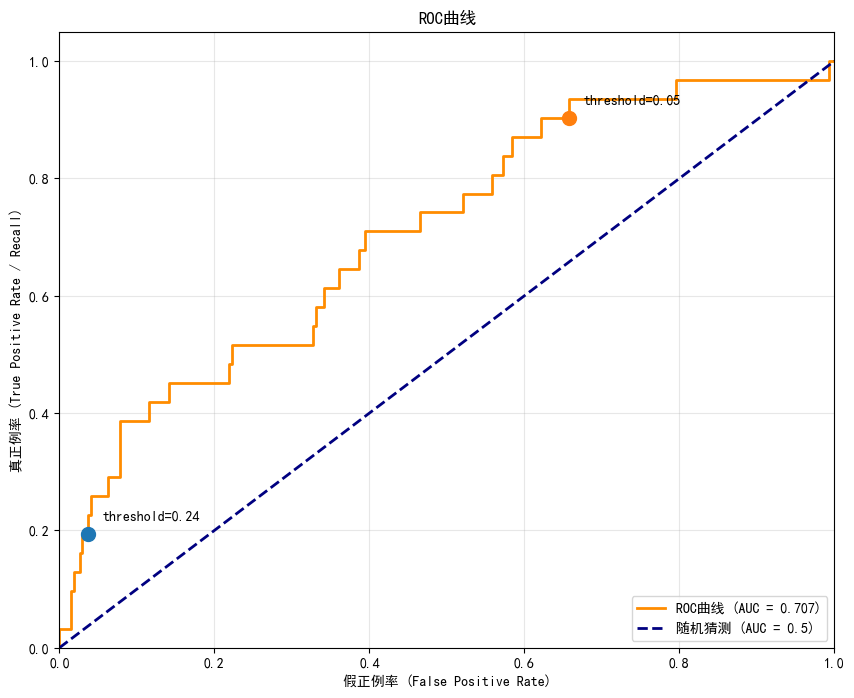


ROC曲线解读:
----------------------------------------
• 横轴 FPR = FP / (FP+TN)  假正例率 (误报率)
• 纵轴 TPR = TP / (TP+FN)  真正例率 (召回率)
• 曲线越靠近左上角，模型越好
• AUC = 0.5 相当于随机猜测
• AUC = 1.0 完美分类器
• AUC > 0.8 通常认为不错


In [7]:
# 计算ROC曲线
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

print(f"\nROC-AUC: {roc_auc:.4f}")

# 绘制ROC曲线
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC曲线 (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='随机猜测 (AUC = 0.5)')

# 标记几个阈值点
for i in [10, 50, 100]:
    if i < len(thresholds):
        plt.scatter(fpr[i], tpr[i], s=100, zorder=5)
        plt.annotate(f'threshold={thresholds[i]:.2f}',
                    (fpr[i], tpr[i]),
                    xytext=(10, 10), textcoords='offset points')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假正例率 (False Positive Rate)')
plt.ylabel('真正例率 (True Positive Rate / Recall)')
plt.title('ROC曲线')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print("\nROC曲线解读:")
print("-" * 40)
print("• 横轴 FPR = FP / (FP+TN)  假正例率 (误报率)")
print("• 纵轴 TPR = TP / (TP+FN)  真正例率 (召回率)")
print("• 曲线越靠近左上角，模型越好")
print("• AUC = 0.5 相当于随机猜测")
print("• AUC = 1.0 完美分类器")
print("• AUC > 0.8 通常认为不错")


---

## 六、PR曲线：不平衡数据的更好选择


**P-R 曲线**（Precision-Recall Curve，精确率-召回率曲线）是评估二分类模型在**不同分类阈值**下性能的另一个核心可视化工具。

与聚焦于“捕捉正例且兼顾误报”的 ROC 曲线不同，P-R 曲线将算力带宽**死死锁定在“正样本（Positive Cases）”的质量与数量上**。

类别不平衡时，ROC 曲线可能过于乐观，PR 曲线更靠谱。

## 1. P-R 曲线的坐标轴

P-R 曲线的横纵坐标同样由混淆矩阵衍生而来：

* **纵坐标：精确率 (Precision) / 查准率**, Precision = TP/ (TP + FP)，核心关注：在模型预测为正的所有样本里，真正的正样本占多大比例？（抓得准不准，防误报）。


* **横坐标：召回率 (Recall) / 查全率（等同于 ROC 的 TPR）**, Recall = TP/ (TP + FN)，核心关注：在全天下所有的正样本里，模型成功捞上来了多少？（抓得全不全，防漏报）。


## 2. 曲线形态与动态调参机制

模型的阈值从 1.0 降到 0.0 的过程中，精确率和召回率呈天生对抗（跷跷板）关系。

* **左上角 (0, 1) 点：** 阈值极高。模型极度谨慎，只对把握最大的一个样本判正。此时误报 FP=0，精确率 Precision=1；但绝大多数正样本被漏报，召回率 Recall ≈ 0。
* **右下角 (1, 正样本比例) 点：** 阈值降为 0。模型把所有样本通通判正。全天下正样本都被捞了回来（Recall=1）；但误报漫天，精确率降到基础的样本不均衡比例。
* **上帝节点 (1, 1)（右上角）：** 查准率 100% 且查全率 100%。**P-R 曲线越往右上角凸起，说明模型性能越优越。**

---

## 3. P-R 曲线 vs ROC 曲线：何时切换算法战场？

这是工业界和面试中最经典的架构抉择：

| 维度 | ROC 曲线（AUC） | P-R 曲线（PR-AUC / AP） |
| --- | --- | --- |
| **核心聚焦** | 均衡关注正例和负例的排序能力。 | **极度偏好正例**，对负例大盘的变动不敏感。 |
| **不平衡样本表现** | 极其稳定。负样本暴增 100 倍，曲线形状几乎不变。 | **极度敏感**。负样本一旦暴增，FP 激增，精确率会断崖式下跌。 |
| **最佳应用场景** | **类别相对平衡**，或者**需要同时评估正负例**的场景（如区分猫和狗）。 | **极度不平衡（稀疏正例）**，且**极其在乎误报**的场景（如广告点击率预测 CTR、犯罪预测）。 |

### 为什么不平衡时 P-R 曲线更敏感？

假设在一个信息流推荐沙盒中，100万个视频里只有 100 个是用户喜欢的（正例）。

* 如果模型表现不佳，把 1000 个不喜欢的视频误报成了喜欢（FP=1000）。
* **对于 ROC 轴：** FPR = 1000 / 999,900 ≈ 0.1%。由于分母（负例）太大，ROC 曲线会显得“极其优秀”（误报率几乎为0），从而**掩盖了模型的无能**。
* **对于 P-R 轴：** Precision = 100 / (100 + 1000) ≈ 9%。精确率直接崩塌到 9%。P-R 曲线会立刻给出刺眼的警报。

因此，在互联网大厂的推荐算法、搜索引擎和反作弊系统中，**P-R 曲线（或 Average Precision, AP）是比 ROC 更高频使用的“降噪监控器”**。

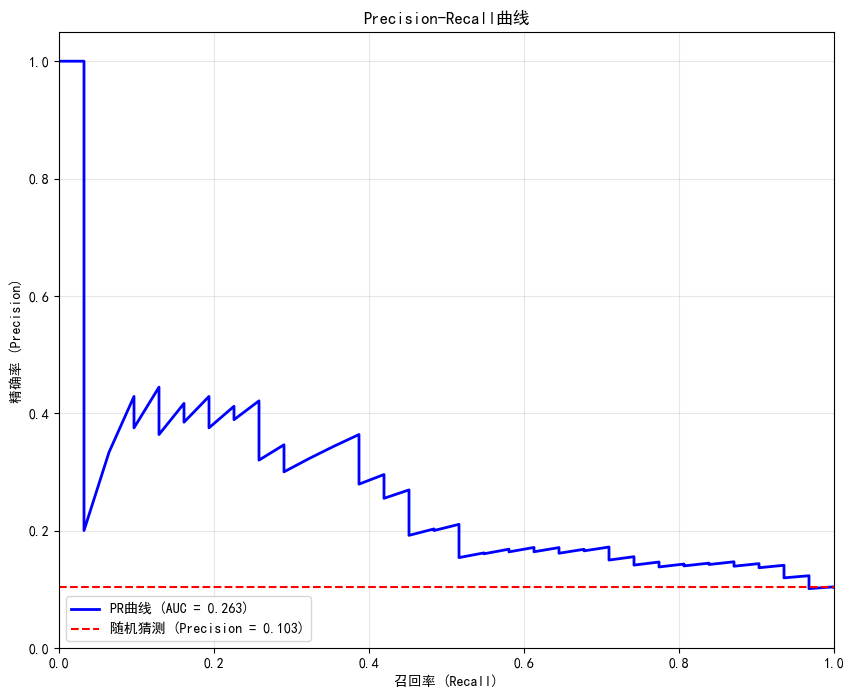


PR曲线解读:
----------------------------------------
• 横轴: 召回率
• 纵轴: 精确率
• 类别不平衡时，PR曲线比ROC更有参考价值
• 曲线越靠近右上角，模型越好
• 关注高召回率时的精确率表现


In [9]:
# 计算PR曲线
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall_curve, precision_curve)

# 绘制PR曲线
plt.figure(figsize=(10, 8))
plt.plot(recall_curve, precision_curve, color='blue', lw=2,
         label=f'PR曲线 (AUC = {pr_auc:.3f})')

# 基准线（随机猜测的PR）
baseline = y_test.mean()
plt.axhline(y=baseline, color='red', linestyle='--', 
           label=f'随机猜测 (Precision = {baseline:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('召回率 (Recall)')
plt.ylabel('精确率 (Precision)')
plt.title('Precision-Recall曲线')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.savefig('pr_curve.png', dpi=150)
plt.show()

print("\nPR曲线解读:")
print("-" * 40)
print("• 横轴: 召回率")
print("• 纵轴: 精确率")
print("• 类别不平衡时，PR曲线比ROC更有参考价值")
print("• 曲线越靠近右上角，模型越好")
print("• 关注高召回率时的精确率表现")


---

## 七、阈值选择：如何确定分类边界

二分类模型分类阈值默认 0.5，但很多时候调一调效果更好：



不同阈值下的指标变化:
      阈值        精确率        召回率         F1        准确率
----------------------------------------------------------------------
     0.1      0.154      0.516      0.237      0.657
     0.2      0.321      0.290      0.305      0.863
     0.3      0.364      0.129      0.190      0.887
     0.4      1.000      0.032      0.062      0.900
     0.5      0.000      0.000      0.000      0.897
     0.6      0.000      0.000      0.000      0.897
     0.7      0.000      0.000      0.000      0.897
     0.8      0.000      0.000      0.000      0.897
     0.9      0.000      0.000      0.000      0.897


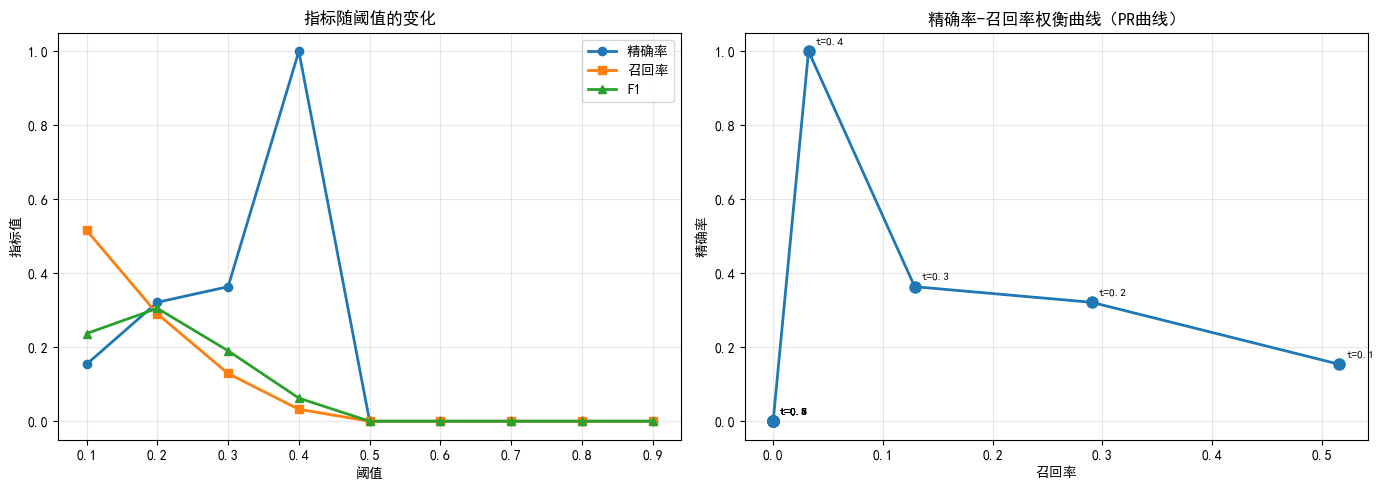

In [13]:
# 分析不同阈值下的指标
print("\n不同阈值下的指标变化:")
print(f"{'阈值':>8} {'精确率':>10} {'召回率':>10} {'F1':>10} {'准确率':>10}")

thresholds_to_check = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
results = []

for thresh in thresholds_to_check:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    
    prec = precision_score(y_test, y_pred_thresh, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
    acc = accuracy_score(y_test, y_pred_thresh)
    
    results.append({
        'threshold': thresh,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'accuracy': acc
    })
    
    print(f"{thresh:>8.1f} {prec:>10.3f} {rec:>10.3f} {f1:>10.3f} {acc:>10.3f}")

results_df = pd.DataFrame(results)

# 可视化阈值影响
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：指标随阈值变化
ax1 = axes[0]
ax1.plot(results_df['threshold'], results_df['precision'], 'o-', label='精确率', linewidth=2)
ax1.plot(results_df['threshold'], results_df['recall'], 's-', label='召回率', linewidth=2)
ax1.plot(results_df['threshold'], results_df['f1'], '^-', label='F1', linewidth=2)
ax1.set_xlabel('阈值')
ax1.set_ylabel('指标值')
ax1.set_title('指标随阈值的变化')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 右图：精确率-召回率权衡
ax2 = axes[1]
ax2.plot(results_df['recall'], results_df['precision'], 'o-', linewidth=2, markersize=8)
for i, row in results_df.iterrows():
    ax2.annotate(f"t={row['threshold']:.1f}",
                (row['recall'], row['precision']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax2.set_xlabel('召回率')
ax2.set_ylabel('精确率')
ax2.set_title('精确率-召回率权衡曲线（PR曲线）')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
print(f"正样本占比: {y_test.mean():.1%}")


正样本占比: 10.3%


由于我们的数据正样本占比只有 10.3%，准确率即使全预测为负也有 89.7%，毫无意义。

- 从左图中可以看到，F1 峰值出现在阈值0.2附近，默认 0.5 并非最优。
- 从左图可以看到，精确率与召回率两条曲线的物理交点也差不多在0.2附近。在这个点，模型“错杀（误报）”和“漏网（漏报）”的概率完全对等。如果业务没有明确的偏好，交点对应的阈值就是一个天然的防御哨所。
- 在右图（PR 曲线）中，最接近右上角 (1,1) 的“拐点”的t=0.2。过了这个阈值标签后，向左看（提高阈值），召回率会断崖式下跌，但精确率却无法再明显提升。它就是系统的最高边际效益点。

阈值选择建议:
• 需要高召回率，减少漏判（如癌症诊断、信用卡欺诈）→ 沿 PR 曲线向右移动，寻找 Recall 足够高（如 >0.8）的阈值标签（通常在 0.1-0.3）。代价是此时的 Precision 会相对较低，但只要它明显高于 baseline (0.103)，模型就依然具有远超随机筛选的净化价值。
• 需要高精确率，减少误判（如垃圾邮件拦截、自动化封号）→ 沿 PR 曲线向左上移动，锁定 Precision 满足要求的阈值标签（如 > 0.7），强行截断，只吃最核心、最确定的一块正样本红利。
• 平衡两者 → 选择F1最高的阈值

---

## 八、多分类评估

多分类（Multi-class Classification）评估是对二分类指标的**高维拓扑扩展**。由于无法直接定义单一的“正例”和“反例”，多分类评估的核心在于“拆解”与“聚合”。

评估多分类模型，通常需要通过以下两个核心路径。

---

### 1. 核心骨架：多分类混淆矩阵

多分类混淆矩阵是一个 $N \times N$ 的矩阵（$N$ 为类别总数）。

* **主对角线（Diagonal）：** 预测正确的样本数。
* **非对角线（Off-diagonal）：** 模型发生“混淆”的重灾区（例如，把第 $i$ 类误判为了第 $j$ 类）。
* **一键解包逻辑：** 在多分类中，我们不能用 `cm.ravel()` 直接解出 `tn, fp, fn, tp`。必须针对**每一个单独的类别 $k$**，将其余所有类别视为“非 $k$ 类”，从而为该类别单独构建一个二分类混淆矩阵：
* $\text{TP}_k$: 本来是 $k$ 且预测为 $k$。
* $\text{FP}_k$: 本来不是 $k$ 但预测为 $k$（各行在第 $k$ 列的非对角线元素之和）。
* $\text{FN}_k$: 本来是 $k$ 但预测不是 $k$（第 $k$ 行在各列的非对角线元素之和）。


### 2. 核心指标的聚合算法

计算出每个类别的 $\text{Precision}_k$ 和 $\text{Recall}_k$ 后，需要通过不同的**权重算法**将它们聚合成一个全局指标。

2.1 Macro-averaging（宏平均）

* **算法：** 算术平均。先计算每个类别的指标，然后直接求平均值。

$$\text{Macro-Precision} = \frac{1}{N}\sum_{k=1}^N \text{Precision}_k$$


* **特点：** **不考虑样本数量，各类别完全平等。**
* **适用场景：** 极度关注小样本类别的表现。如果小类别预测极烂，Macro 指标会直接崩塌。

2.2 Micro-averaging（微平均）

* **算法：** 全局汇总。先把所有类别的 $\text{TP}_k, \text{FP}_k, \text{FN}_k$ 累加起来，再统一计算指标。

$$\text{Micro-Precision} = \frac{\sum \text{TP}_k}{\sum \text{TP}_k + \sum \text{FP}_k}$$


* **特点：** 每个样本完全平等。**在大盘不平衡时，Micro 指标会被大样本类别“绑架”。**
* *注：在多分类中，$\text{Micro-Precision} = \text{Micro-Recall} = \text{Micro-F1} = \text{Accuracy}$（准确率）。*

2.3 Weighted-averaging（加权平均）

* **算法：** 比例加权。根据每个类别在测试集中的实际样本占比（Support）作为权重进行加权平均。
* **特点：** 兼顾了类别结构，但对小类别的误判漏判有一定的容忍度。

下面我们用手写数字数据集（0~9 十类分类）演示：二分类指标如何扩展到多分类，并重点解释宏平均 (macro) / 加权平均 (weighted)的区别。

In [19]:
print("多分类评估示例")

from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier

# 加载手写数字数据
digits = load_digits()
X_d, y_d = digits.data, digits.target

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d, y_d, test_size=0.2, random_state=42, stratify=y_d)

# 训练模型
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_d, y_train_d)
y_pred_d = rf.predict(X_test_d)

# 多分类指标
print("\n多分类评估指标:")
print("-" * 40)
print(f"准确率: {accuracy_score(y_test_d, y_pred_d):.4f}")

# 宏平均 vs 加权平均
print(f"\n宏平均 (macro):")
print(f"  精确率: {precision_score(y_test_d, y_pred_d, average='macro'):.4f}")
print(f"  召回率: {recall_score(y_test_d, y_pred_d, average='macro'):.4f}")
print(f"  F1:     {f1_score(y_test_d, y_pred_d, average='macro'):.4f}")

print(f"\n加权平均 (weighted):")
print(f"  精确率: {precision_score(y_test_d, y_pred_d, average='weighted'):.4f}")
print(f"  召回率: {recall_score(y_test_d, y_pred_d, average='weighted'):.4f}")
print(f"  F1:     {f1_score(y_test_d, y_pred_d, average='weighted'):.4f}")

print("\n宏平均 vs 加权平均:")
print("-" * 40)
print("• 宏平均: 每个类别同等重要，适合类别平衡")
print("• 加权平均: 考虑类别样本数，适合类别不平衡")

# 完整分类报告
print("\n完整分类报告:")
print("=" * 60)
print(classification_report(y_test_d, y_pred_d, target_names=[str(i) for i in range(10)]))


多分类评估示例

多分类评估指标:
----------------------------------------
准确率: 0.9611

宏平均 (macro):
  精确率: 0.9620
  召回率: 0.9607
  F1:     0.9607

加权平均 (weighted):
  精确率: 0.9620
  召回率: 0.9611
  F1:     0.9609

宏平均 vs 加权平均:
----------------------------------------
• 宏平均: 每个类别同等重要，适合类别平衡
• 加权平均: 考虑类别样本数，适合类别不平衡

完整分类报告:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.90      0.97      0.93        36
           2       1.00      0.97      0.99        35
           3       0.97      0.97      0.97        37
           4       0.97      0.97      0.97        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.92      1.00      0.96        36
           8       0.94      0.86      0.90        35
           9       0.97      0.92      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96   

---

## 九、混淆矩阵多分类可视化

下面我们画出上面多分类（10 个数字）的混淆矩阵，并自动找出模型最容易认错的数字对。

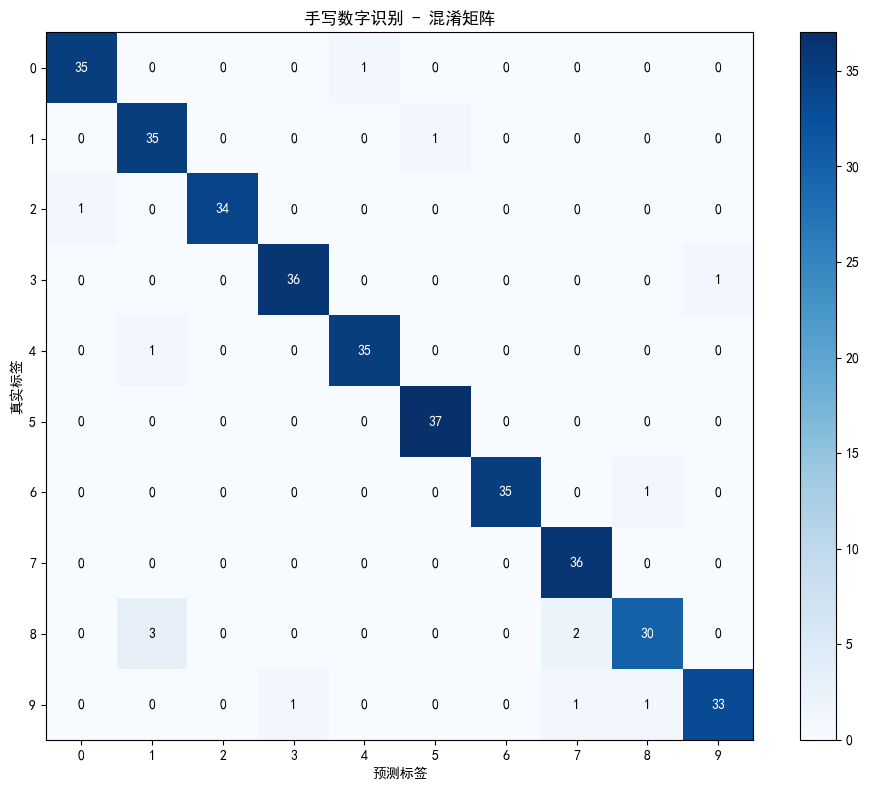


容易混淆的数字对:
----------------------------------------
真实0被预测为4: 1次
真实1被预测为5: 1次
真实2被预测为0: 1次
真实3被预测为9: 1次
真实4被预测为1: 1次
真实6被预测为8: 1次
真实8被预测为1: 3次
真实8被预测为7: 2次
真实9被预测为3: 1次
真实9被预测为7: 1次
真实9被预测为8: 1次


In [17]:
# 多分类混淆矩阵
cm_multi = confusion_matrix(y_test_d, y_pred_d)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_multi, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=np.arange(cm_multi.shape[1]),
       yticks=np.arange(cm_multi.shape[0]),
       xticklabels=range(10),
       yticklabels=range(10),
       title='手写数字识别 - 混淆矩阵',
       ylabel='真实标签',
       xlabel='预测标签')

# 添加数值标注
thresh = cm_multi.max() / 2.
for i in range(cm_multi.shape[0]):
    for j in range(cm_multi.shape[1]):
        ax.text(j, i, format(cm_multi[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm_multi[i, j] > thresh else "black",
                fontsize=10)

plt.tight_layout()
plt.show()

# 找出容易混淆的数字
print("\n容易混淆的数字对:")
print("-" * 40)
for i in range(10):
    for j in range(10):
        if i != j and cm_multi[i, j] > 0:
            print(f"真实{i}被预测为{j}: {cm_multi[i, j]}次")


---

## 十、分类模型综合性能对比

了解了这么多，我们再跟前面学习的几个模型综合复习一下，下面还是用之前的的正样本占比10.3%的不平衡测试数据，对逻辑回归、SVM、KNN、随机森林四种经典分类模型进行综合性能对比，通过准确率、精确率、召回率、F1 分数与 AUC 五项指标全面评估模型效果，并通过柱状图直观展示各模型在不同指标下的优劣，为实际场景中模型的选择提供依据。


四种分类器性能对比:
                模型    准确率    精确率    召回率     F1    AUC
LogisticRegression 0.8967 0.0000 0.0000 0.0000 0.7069
               SVM 0.9000 1.0000 0.0323 0.0625 0.6956
               KNN 0.9000 0.5714 0.1290 0.2105 0.6578
      RandomForest 0.9100 1.0000 0.1290 0.2286 0.7159


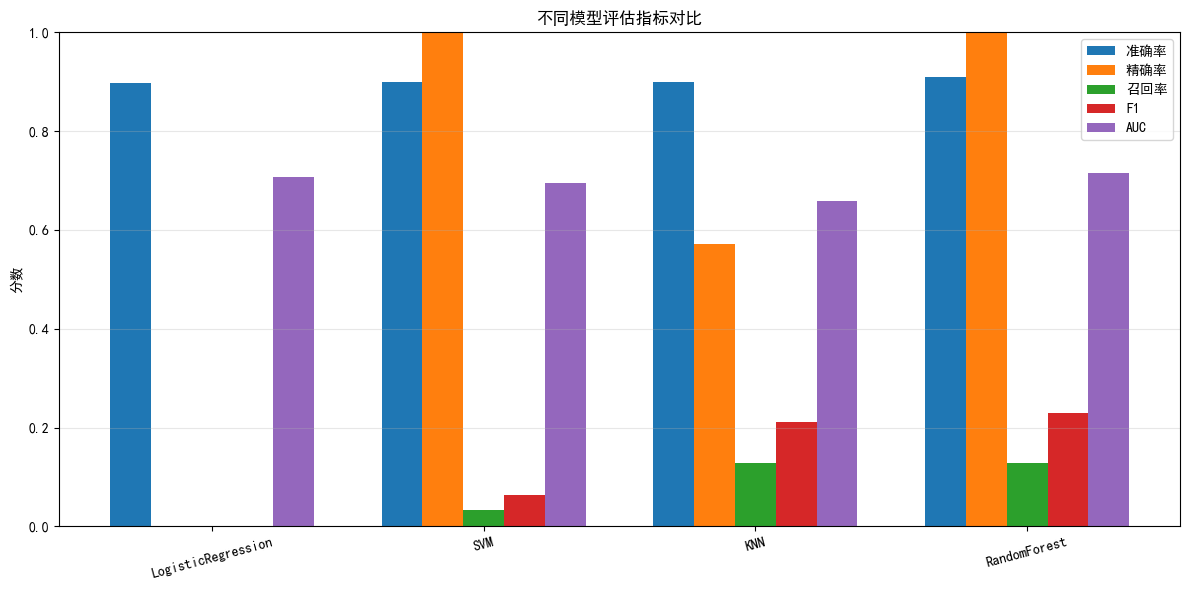

In [25]:
# 创建综合对比表
print("\n四种分类器性能对比:")

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# 在原始不平衡数据上对比多个模型
models = {
    'LogisticRegression': LogisticRegression(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42)
}

comparison = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_m = model.predict(X_test)
    y_proba_m = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    result = {
        '模型': name,
        '准确率': accuracy_score(y_test, y_pred_m),
        '精确率': precision_score(y_test, y_pred_m, zero_division=0),
        '召回率': recall_score(y_test, y_pred_m, zero_division=0),
        'F1': f1_score(y_test, y_pred_m, zero_division=0)
    }
    
    if y_proba_m is not None:
        fpr_m, tpr_m, _ = roc_curve(y_test, y_proba_m)
        result['AUC'] = auc(fpr_m, tpr_m)
    else:
        result['AUC'] = np.nan
    
    comparison.append(result)

comparison_df = pd.DataFrame(comparison)
print(comparison_df.round(4).to_string(index=False))

# 可视化对比
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.15

metrics = ['准确率', '精确率', '召回率', 'F1', 'AUC']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, metric in enumerate(metrics):
    offset = (i - 2) * width
    ax.bar(x + offset, comparison_df[metric], width, label=metric, color=colors[i])

ax.set_ylabel('分数')
ax.set_title('不同模型评估指标对比')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['模型'], rotation=15)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


从上图可以看到：

- 随机森林通常最强，召回率、AUC，F1都最高（集成模型，适合不平衡数据）
- KNN 表现一般（对高维、不平衡数据不占优势）
- 准确率都很高，但没用（因为数据不平衡）

真正看实力要看 F1、召回率、AUC

---

## 十一、小结

| 指标 | 公式 | 关注重点 | 适用场景 |
|------|------|----------|----------|
| **准确率** | (TP+TN)/总数 | 整体正确率 | 类别平衡 |
| **精确率** | TP/(TP+FP) | 误报 | 垃圾邮件过滤 |
| **召回率** | TP/(TP+FN) | 漏报 | 疾病筛查 |
| **F1** | 2PR/(P+R) | 两者平衡 | 信息检索 |
| **AUC-ROC** | ROC曲线下面积 | 区分能力 | 模型选择 |
| **AUC-PR** | PR曲线下面积 | 不平衡数据 | 正例稀少时 |

**关键要点**：
1. 类别不平衡时，不要只看准确率
2. 根据业务场景选择优先指标
3. ROC-AUC不受阈值影响，适合模型比较
4. PR曲线在类别不平衡时更有参考价值
5. 阈值可以根据业务需求调整

---

## 十二、课后练习

1. 在一个类别不平衡的数据集上，对比不同模型的Precision、Recall和F1
2. 尝试调整分类阈值，观察Precision和Recall的变化
3. 画出不同模型的ROC曲线，比较AUC
4. 思考：为什么疾病筛查更关注Recall，而垃圾邮件过滤更关注Precision？

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_iris, load_digits
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                            confusion_matrix, roc_curve, auc,
                            precision_score, recall_score, f1_score,
                            precision_recall_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

# seaborn 主题会覆盖字体设置，重新指定中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 练习1：类别不平衡数据集上对比不同模型的Precision、Recall和F1
# ============================================================
print("=" * 60)
print("练习1：类别不平衡数据集上的模型评估")
print("=" * 60)

# 生成不平衡数据（90%类别0，10%类别1）
X, y = make_classification(n_samples=2000, n_features=20, n_informative=10,
                           n_redundant=5, weights=[0.9, 0.1], random_state=42)
print(f"\n数据集: {X.shape[0]}条, 类别分布: 0类={np.sum(y==0)}, 1类={np.sum(y==1)} (比例 {(np.sum(y==1)/len(y)*100):.1f}%)")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"\n训练集类别分布: 0类={np.sum(y_train==0)}, 1类={np.sum(y_train==1)}")
print(f"测试集类别分布: 0类={np.sum(y_test==0)}, 1类={np.sum(y_test==1)}")

# 训练多个模型
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    results.append({'模型': name, '准确率': acc, '精确率': prec, '召回率': rec, 'F1': f1})
    print(f"\n  {name}:")
    print(f"    准确率={acc:.4f}, 精确率={prec:.4f}, 召回率={rec:.4f}, F1={f1:.4f}")

df_results = pd.DataFrame(results)
print(f"\n{df_results.to_string(index=False)}")

# 可视化
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(models))
w = 0.2
metrics_names = ['准确率', '精确率', '召回率', 'F1']
colors = ['steelblue', 'coral', 'mediumseagreen', 'purple']
for i, (metric, color) in enumerate(zip(metrics_names, colors)):
    vals = [r[metric] for r in results]
    ax.bar(x + i * w, vals, w, label=metric, color=color, alpha=0.8)

ax.set_xticks(x + 1.5 * w)
ax.set_xticklabels(list(models.keys()), rotation=15)
ax.set_title('练习1 - 类别不平衡数据集上不同模型的评估指标对比', fontsize=14)
ax.set_ylabel('分数', fontsize=12)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.close()

练习1：类别不平衡数据集上的模型评估

数据集: 2000条, 类别分布: 0类=1792, 1类=208 (比例 10.4%)

训练集类别分布: 0类=1254, 1类=146
测试集类别分布: 0类=538, 1类=62

  LogisticRegression:
    准确率=0.9267, 精确率=0.7500, 召回率=0.4355, F1=0.5510

  DecisionTree:
    准确率=0.8967, 精确率=0.5000, 召回率=0.5000, F1=0.5000

  RandomForest:
    准确率=0.9233, 精确率=0.8333, 召回率=0.3226, F1=0.4651

  SVM:
    准确率=0.9533, 精确率=0.9250, 召回率=0.5968, F1=0.7255

                模型      准确率      精确率      召回率       F1
LogisticRegression 0.926667 0.750000 0.435484 0.551020
      DecisionTree 0.896667 0.500000 0.500000 0.500000
      RandomForest 0.923333 0.833333 0.322581 0.465116
               SVM 0.953333 0.925000 0.596774 0.725490



练习2：调整分类阈值对Precision和Recall的影响

阈值    精确率    召回率    F1
-----------------------------------
  0.05    0.2381    0.9677    0.3822
  0.20    0.4947    0.7581    0.5987
  0.95    1.0000    0.0484    0.0923

最佳阈值: 0.20 (F1=0.5987)


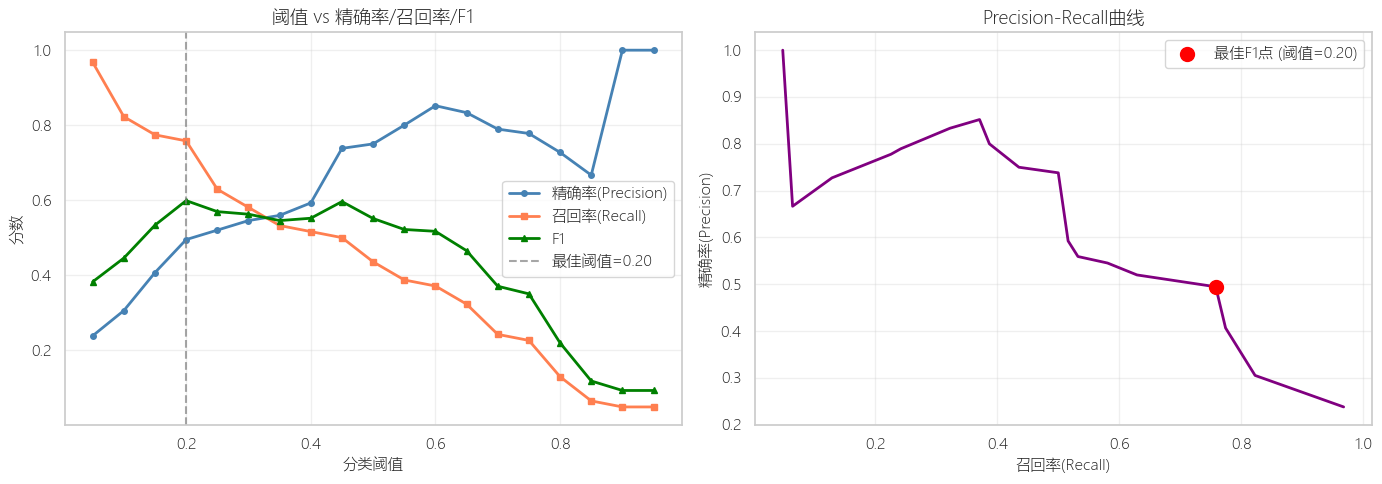

In [2]:
# ============================================================
# 练习2：调整分类阈值，观察Precision和Recall的变化
# ============================================================
print("\n" + "=" * 60)
print("练习2：调整分类阈值对Precision和Recall的影响")
print("=" * 60)

# 使用逻辑回归的概率输出
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)
y_proba = lr.predict_proba(X_test_s)[:, 1]  # 正类概率

thresholds = np.arange(0.05, 1.0, 0.05)
precisions = []
recalls = []
f1s = []

for thresh in thresholds:
    y_pred_t = (y_proba >= thresh).astype(int)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

# 找到F1最大的阈值
best_idx = np.argmax(f1s)
print(f"\n阈值    精确率    召回率    F1")
print("-" * 35)
for i in [0, best_idx, len(thresholds)-1]:
    print(f"  {thresholds[i]:.2f}    {precisions[i]:.4f}    {recalls[i]:.4f}    {f1s[i]:.4f}")
print(f"\n最佳阈值: {thresholds[best_idx]:.2f} (F1={f1s[best_idx]:.4f})")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, precisions, 'o-', label='精确率(Precision)', color='steelblue', linewidth=2, markersize=4)
axes[0].plot(thresholds, recalls, 's-', label='召回率(Recall)', color='coral', linewidth=2, markersize=4)
axes[0].plot(thresholds, f1s, '^-', label='F1', color='green', linewidth=2, markersize=4)
axes[0].axvline(x=thresholds[best_idx], color='gray', linestyle='--', alpha=0.7,
                label=f'最佳阈值={thresholds[best_idx]:.2f}')
axes[0].set_title('阈值 vs 精确率/召回率/F1', fontsize=13)
axes[0].set_xlabel('分类阈值', fontsize=11)
axes[0].set_ylabel('分数', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall曲线
axes[1].plot(recalls, precisions, '-', color='purple', linewidth=2)
axes[1].scatter(recalls[best_idx], precisions[best_idx], color='red', s=100, zorder=5,
                label=f'最佳F1点 (阈值={thresholds[best_idx]:.2f})')
axes[1].set_title('Precision-Recall曲线', fontsize=13)
axes[1].set_xlabel('召回率(Recall)', fontsize=11)
axes[1].set_ylabel('精确率(Precision)', fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()



练习3：不同模型的ROC曲线与AUC对比
  LogisticRegression: AUC=0.9018
  DecisionTree: AUC=0.7212
  RandomForest: AUC=0.9357
  SVM: AUC=0.9438


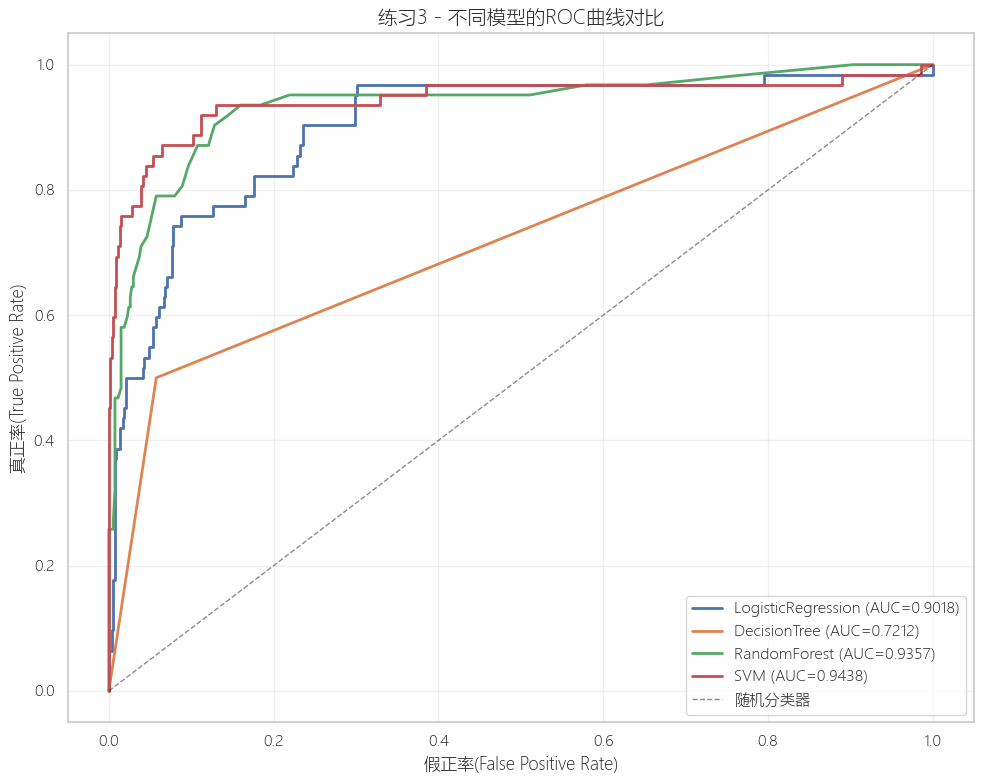

In [3]:
# ============================================================
# 练习3：画出不同模型的ROC曲线，比较AUC
# ============================================================
print("\n" + "=" * 60)
print("练习3：不同模型的ROC曲线与AUC对比")
print("=" * 60)

plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_proba = model.predict_proba(X_test_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={roc_auc_val:.4f})')
    print(f"  {name}: AUC={roc_auc_val:.4f}")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='随机分类器')
plt.xlabel('假正率(False Positive Rate)', fontsize=12)
plt.ylabel('真正率(True Positive Rate)', fontsize=12)
plt.title('练习3 - 不同模型的ROC曲线对比', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

A: 疾病筛查场景（高Recall优先）：
   1. 漏诊（假阴性FN）的代价极高——患者错过治疗时机，可能危及生命
   2. 误诊（假阳性FP）的代价相对较低——多做一次检查而已，不会造成伤害
   3. Recall = TP/(TP+FN)，最大化Recall意味着尽量减少漏诊
   4. 策略：宁可"杀错"一千，不可放过一个（降低阈值，宁可误报也不漏报）

   垃圾邮件过滤场景（高Precision优先）：
   1. 将正常邮件误判为垃圾邮件（假阳性FP）的代价极高——用户可能错过重要邮件
      （如工作通知、银行信息等）
   2. 漏掉一封垃圾邮件（假阴性FN）的代价较低——用户多看一封广告而已
   3. Precision = TP/(TP+FP)，最大化Precision意味着减少误判正常邮件
   4. 策略：宁可放过垃圾邮件，也不能把正常邮件误删

   总结：
   - 关注Recall：漏掉正类的代价 >> 误判负类的代价
   - 关注Precision：误判负类的代价 >> 漏掉正类的代价
   - 实际应用中应根据业务成本来选择合适的指标和阈值

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 54 篇：交叉验证与超参数调优**
>
> 下篇学交叉验证与超参数调优——网格搜索、随机搜索、贝叶斯优化，学会科学地调参，让模型性能更上一层楼。

---

*有任何问题，欢迎在评论区留言，小荷会一一回复的！*